In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from stylegan2_core import StyleGAN2Generator, style_mixing_demo, LATENT_DIM

tf.random.set_seed(42)
np.random.seed(42)


In [2]:
gen = StyleGAN2Generator()
z = tf.random.normal((4, LATENT_DIM))
rgbs = gen(z)
res_labels = [r.shape[1] for r in rgbs]
print(res_labels)


[4, 8, 16, 32]


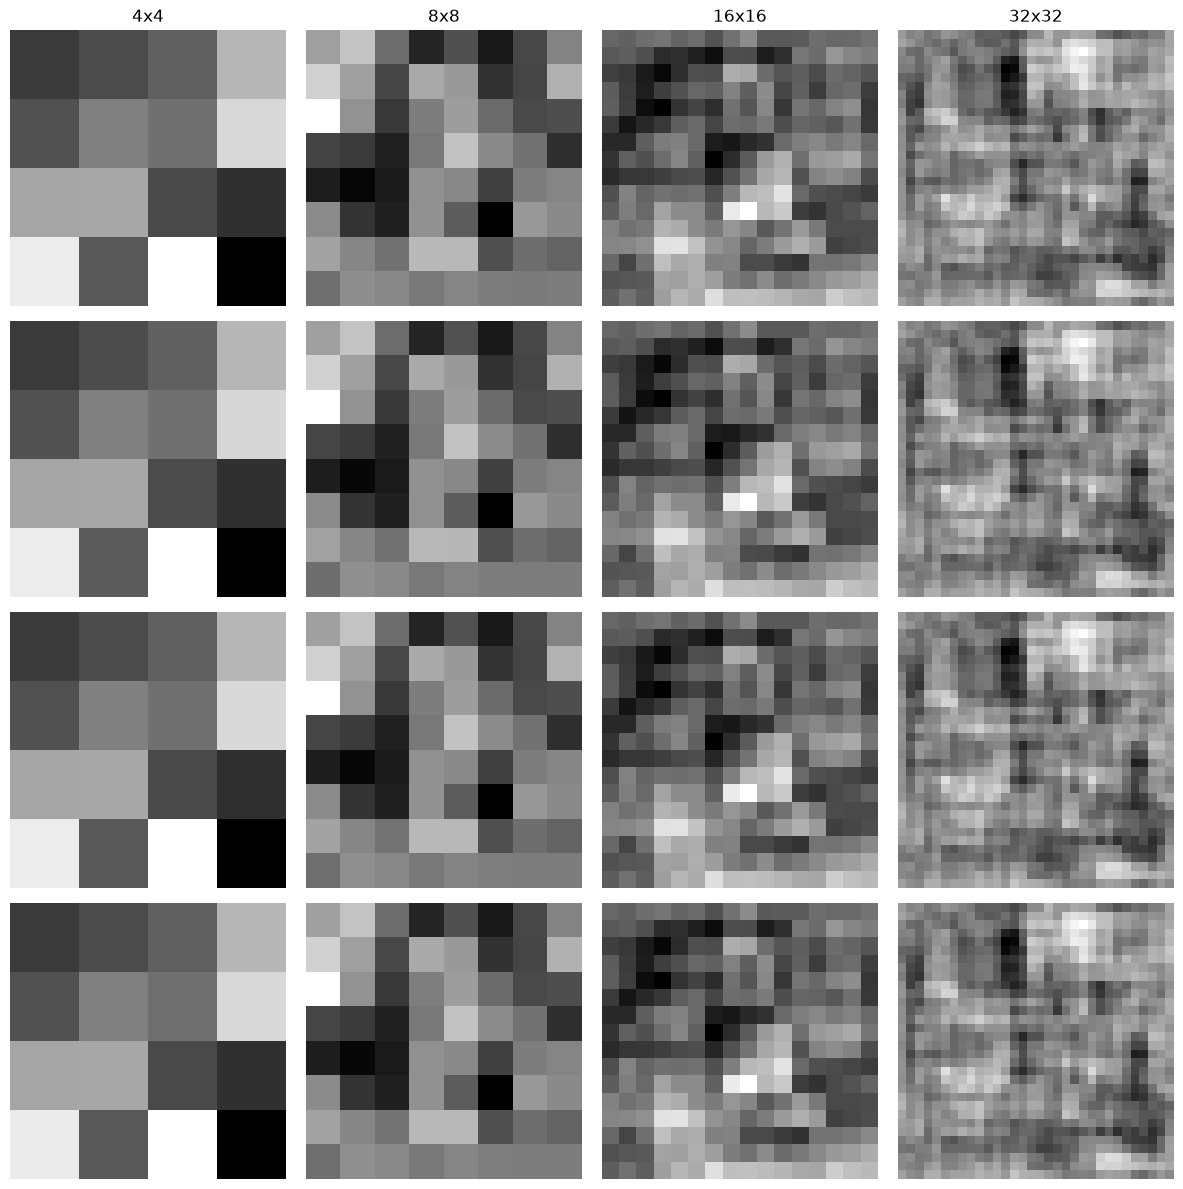

In [3]:
fig, axes = plt.subplots(4, len(rgbs), figsize=(3 * len(rgbs), 12))
for row in range(4):
    for col, rgb in enumerate(rgbs):
        img = (rgb[row, ..., 0].numpy() + 1) / 2
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"{res_labels[col]}x{res_labels[col]}")
plt.tight_layout()
plt.show()


In [4]:
n_samples = 6
z1 = tf.random.normal((n_samples, LATENT_DIM))
z2 = tf.random.normal((n_samples, LATENT_DIM))

coarse_only = gen(z1, w_mix=z2, mix_at=1)[-1]
fine_only = gen(z1, w_mix=z2, mix_at=2)[-1]
no_mix = gen(z1)[-1]


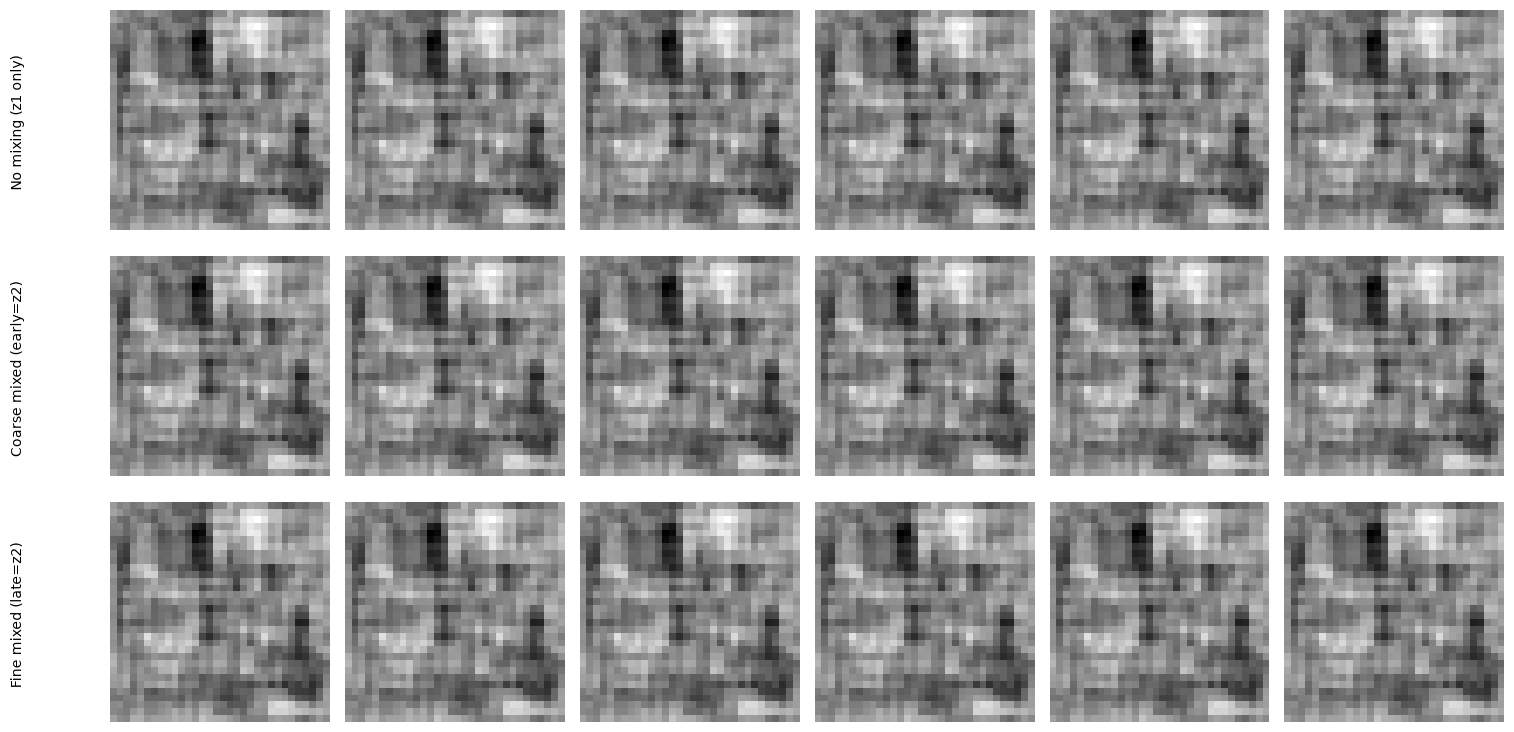

In [5]:
fig, axes = plt.subplots(3, n_samples, figsize=(2.5 * n_samples, 7.5))
titles = ["No mixing (z1 only)", "Coarse mixed (early=z2)", "Fine mixed (late=z2)"]
for row, (imgs, title) in enumerate(zip([no_mix, coarse_only, fine_only], titles)):
    for col in range(n_samples):
        img = (imgs[col, ..., 0].numpy() + 1) / 2
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(title)
for row, title in enumerate(titles):
    axes[row, 0].text(-15, 16, title, rotation=90, va="center")
plt.tight_layout()
plt.show()
